INICIANDO PIPELINE: Breast Cancer Classification

ETAPA 1: ENQUADRAR O PROBLEMA
Metadados do dataset: {'numRows': 569, 'numColumns': 31, 'missingValuesByColumn': {'mean_radius': 0, 'mean_texture': 0, 'mean_perimeter': 0, 'mean_area': 0, 'mean_smoothness': 0, 'mean_compactness': 0, 'mean_concavity': 0, 'mean_concave_points': 0, 'mean_symmetry': 0, 'mean_fractal_dimension': 0, 'radius_error': 0, 'texture_error': 0, 'perimeter_error': 0, 'area_error': 0, 'smoothness_error': 0, 'compactness_error': 0, 'concavity_error': 0, 'concave_points_error': 0, 'symmetry_error': 0, 'fractal_dimension_error': 0, 'worst_radius': 0, 'worst_texture': 0, 'worst_perimeter': 0, 'worst_area': 0, 'worst_smoothness': 0, 'worst_compactness': 0, 'worst_concavity': 0, 'worst_concave_points': 0, 'worst_symmetry': 0, 'worst_fractal_dimension': 0, 'target': 0}, 'sampleOfRows':    mean_radius  mean_texture  mean_perimeter  mean_area  mean_smoothness  \
0        17.99         10.38          122.80     1001.0          0

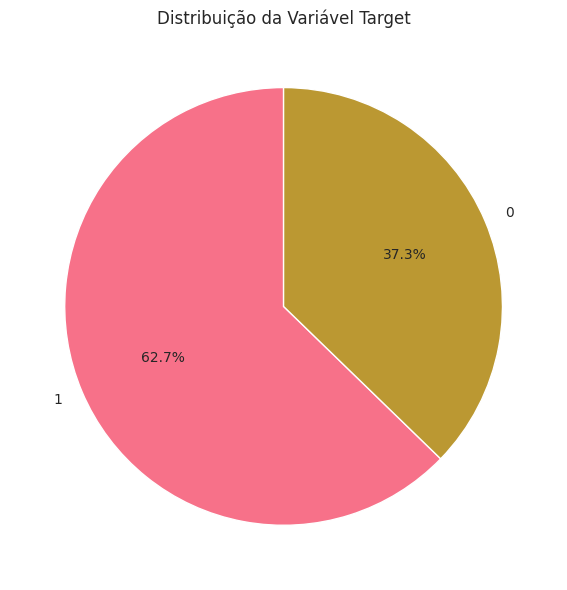

   Visualizando distribuição do target


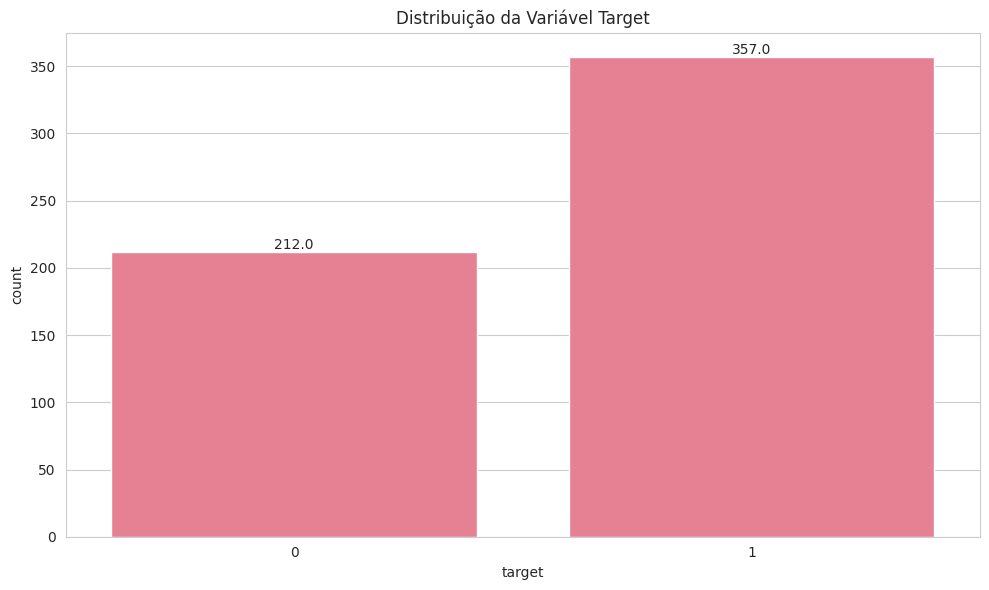

5. Visualizando atributos numéricos (histogramas + KDE)


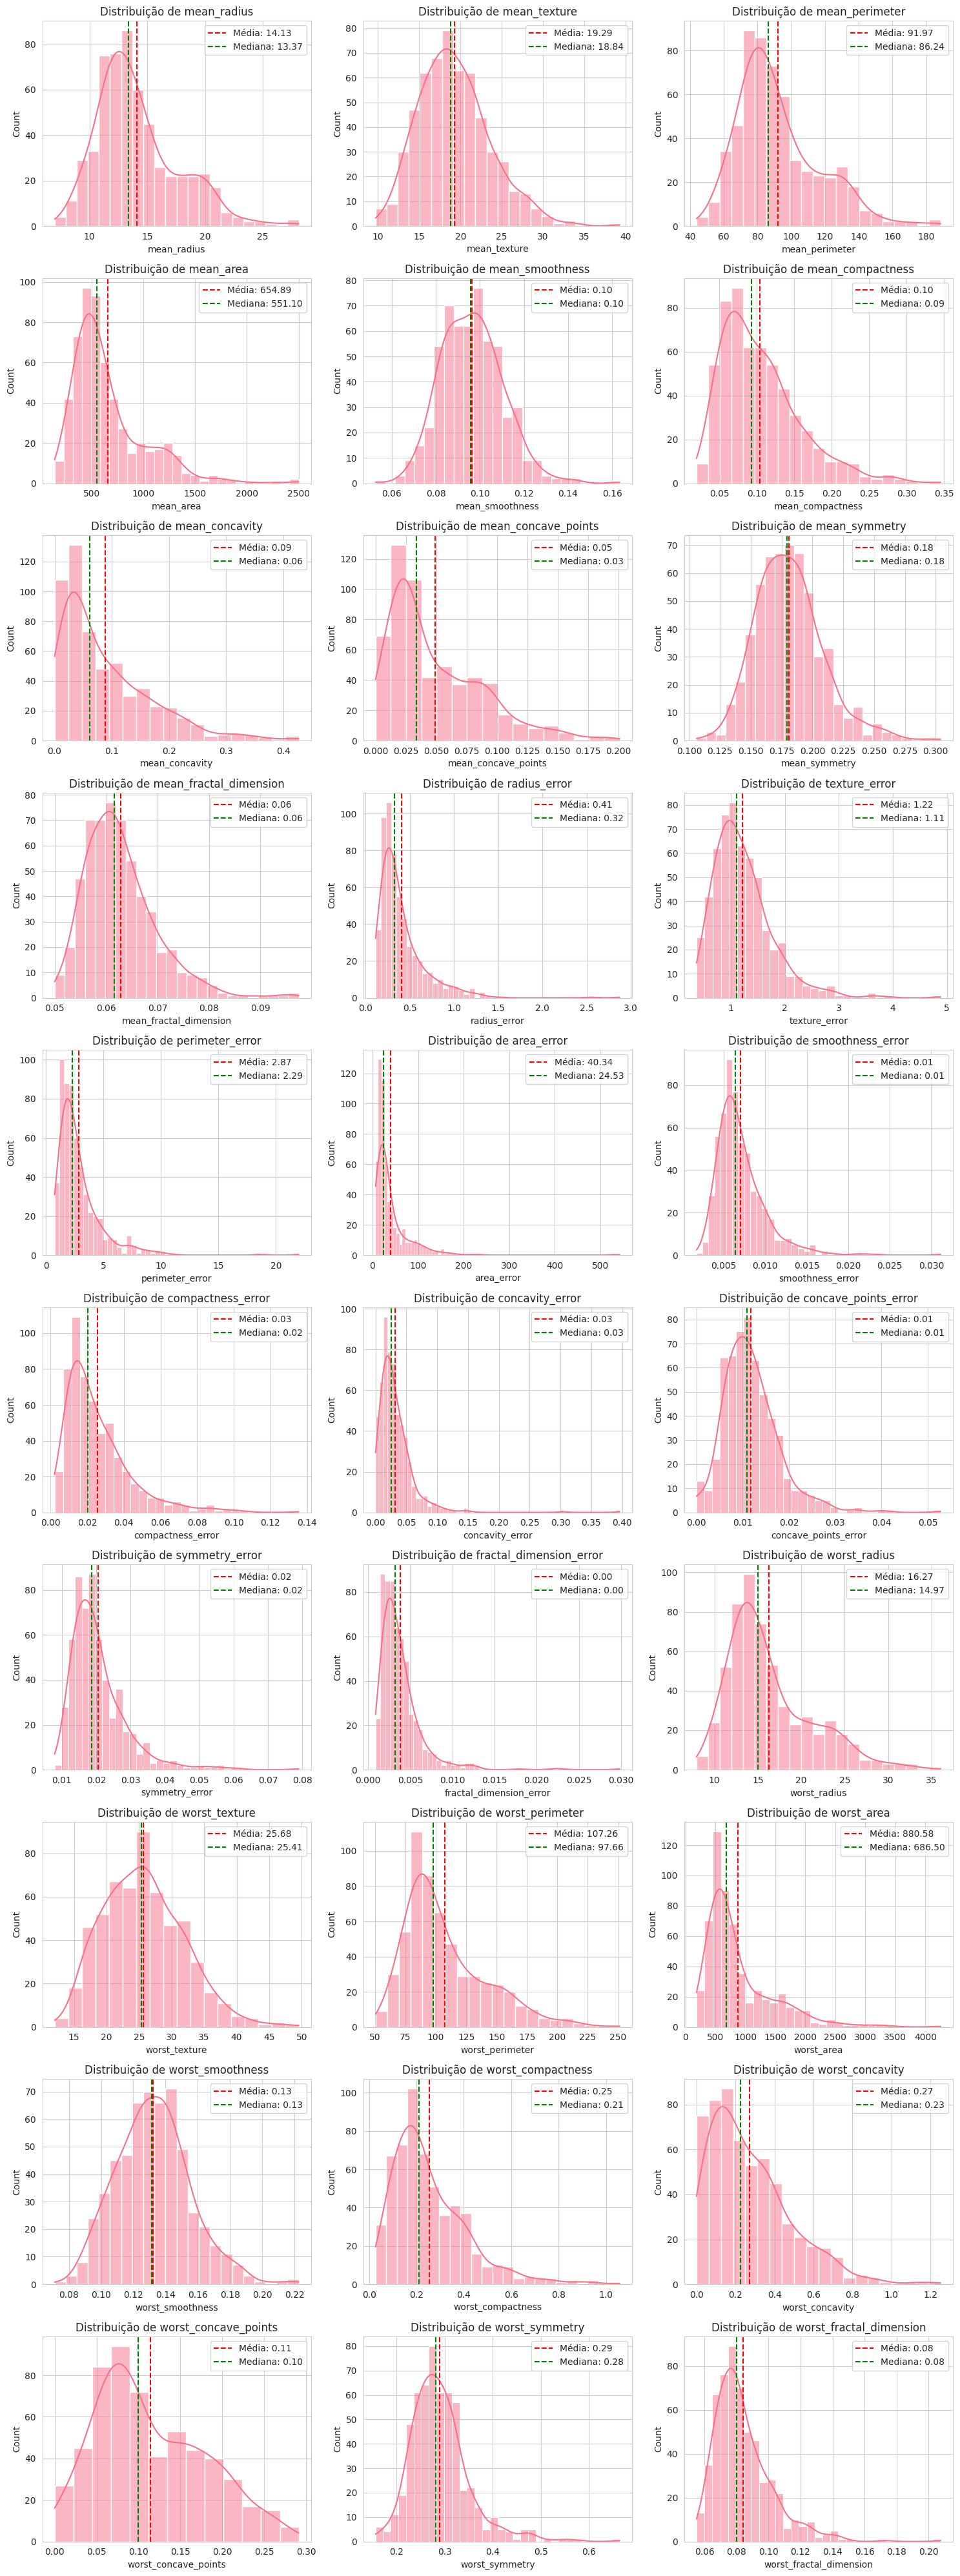

   Visualizando boxplots das características por target


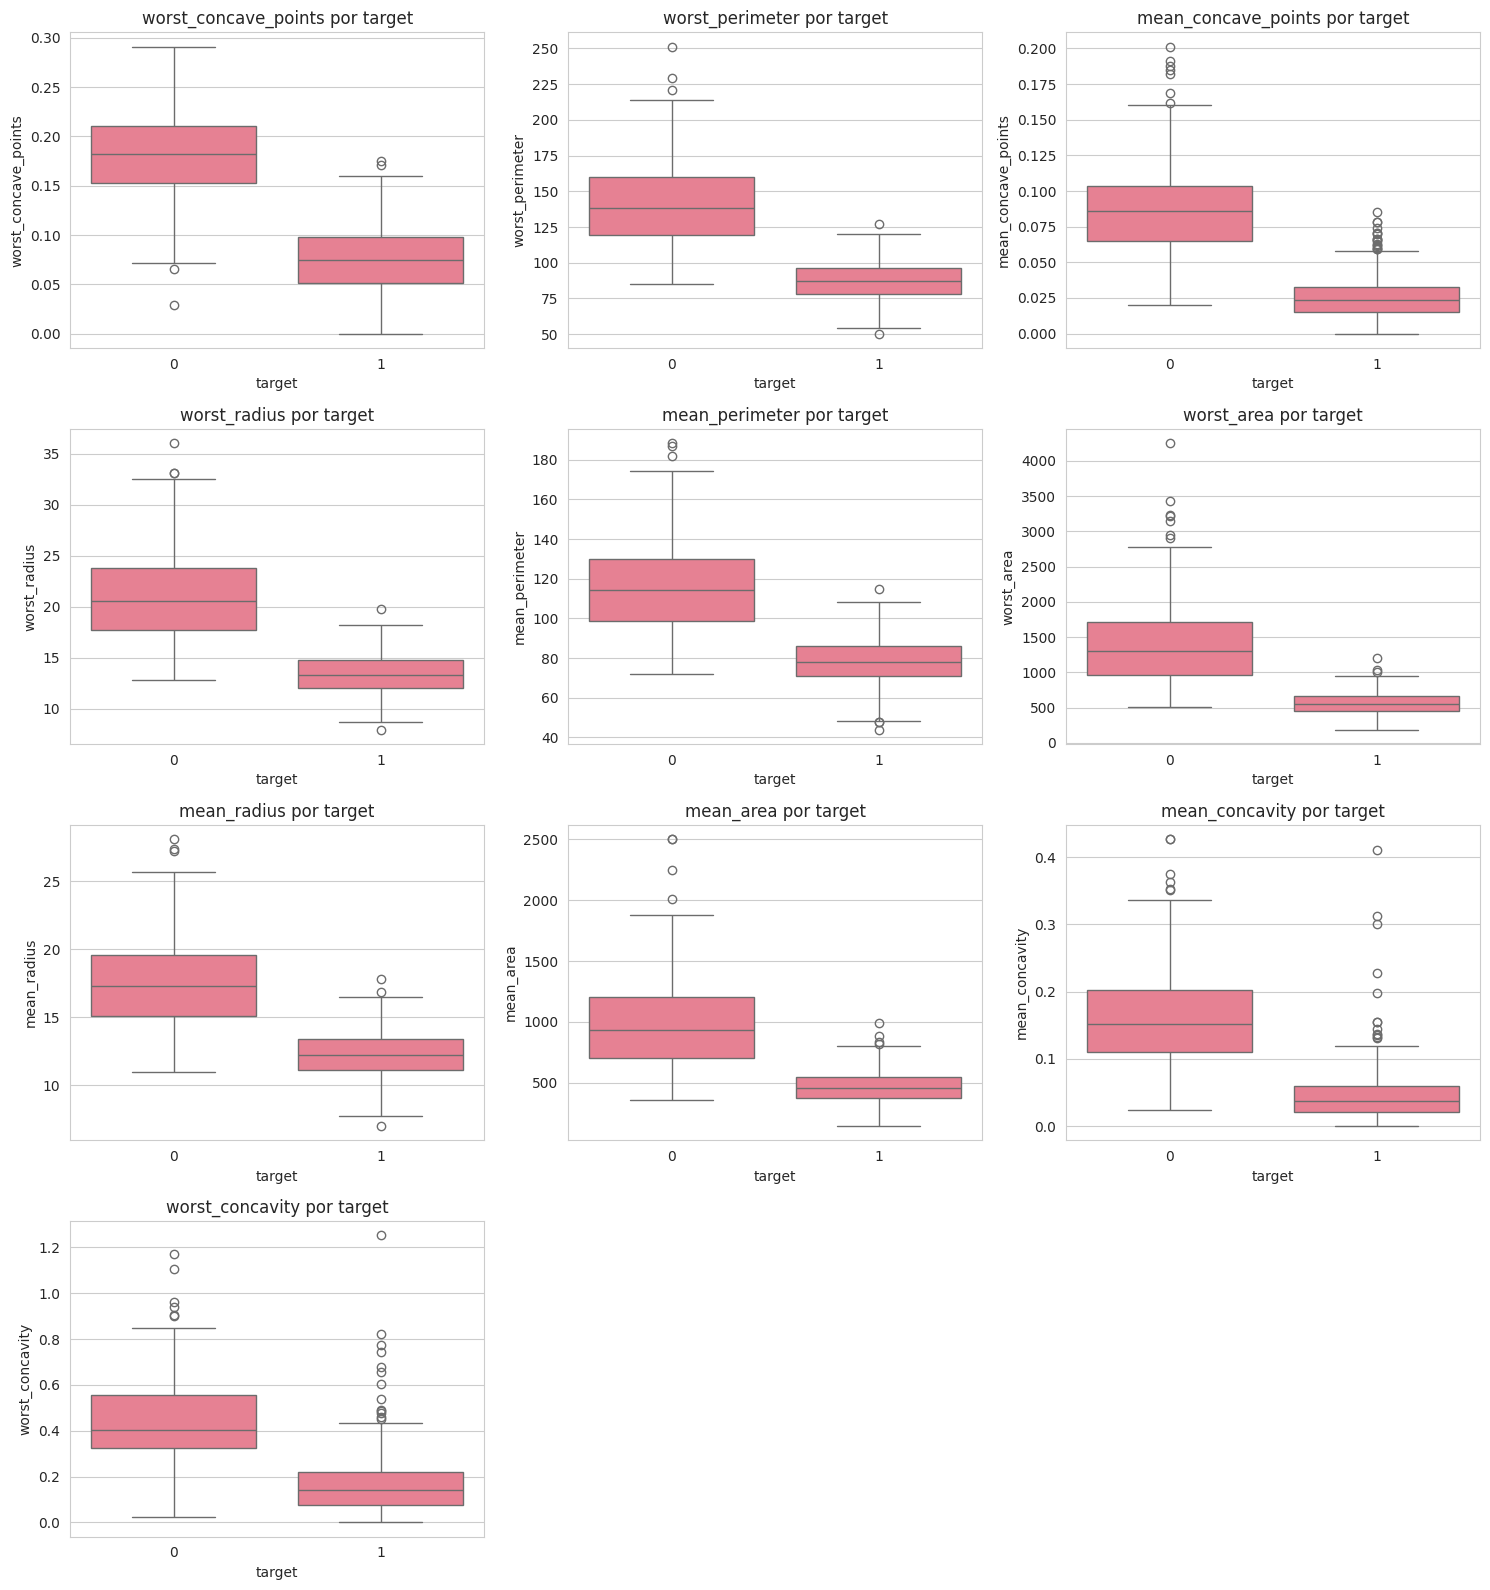

6. Estudando correlações entre atributos


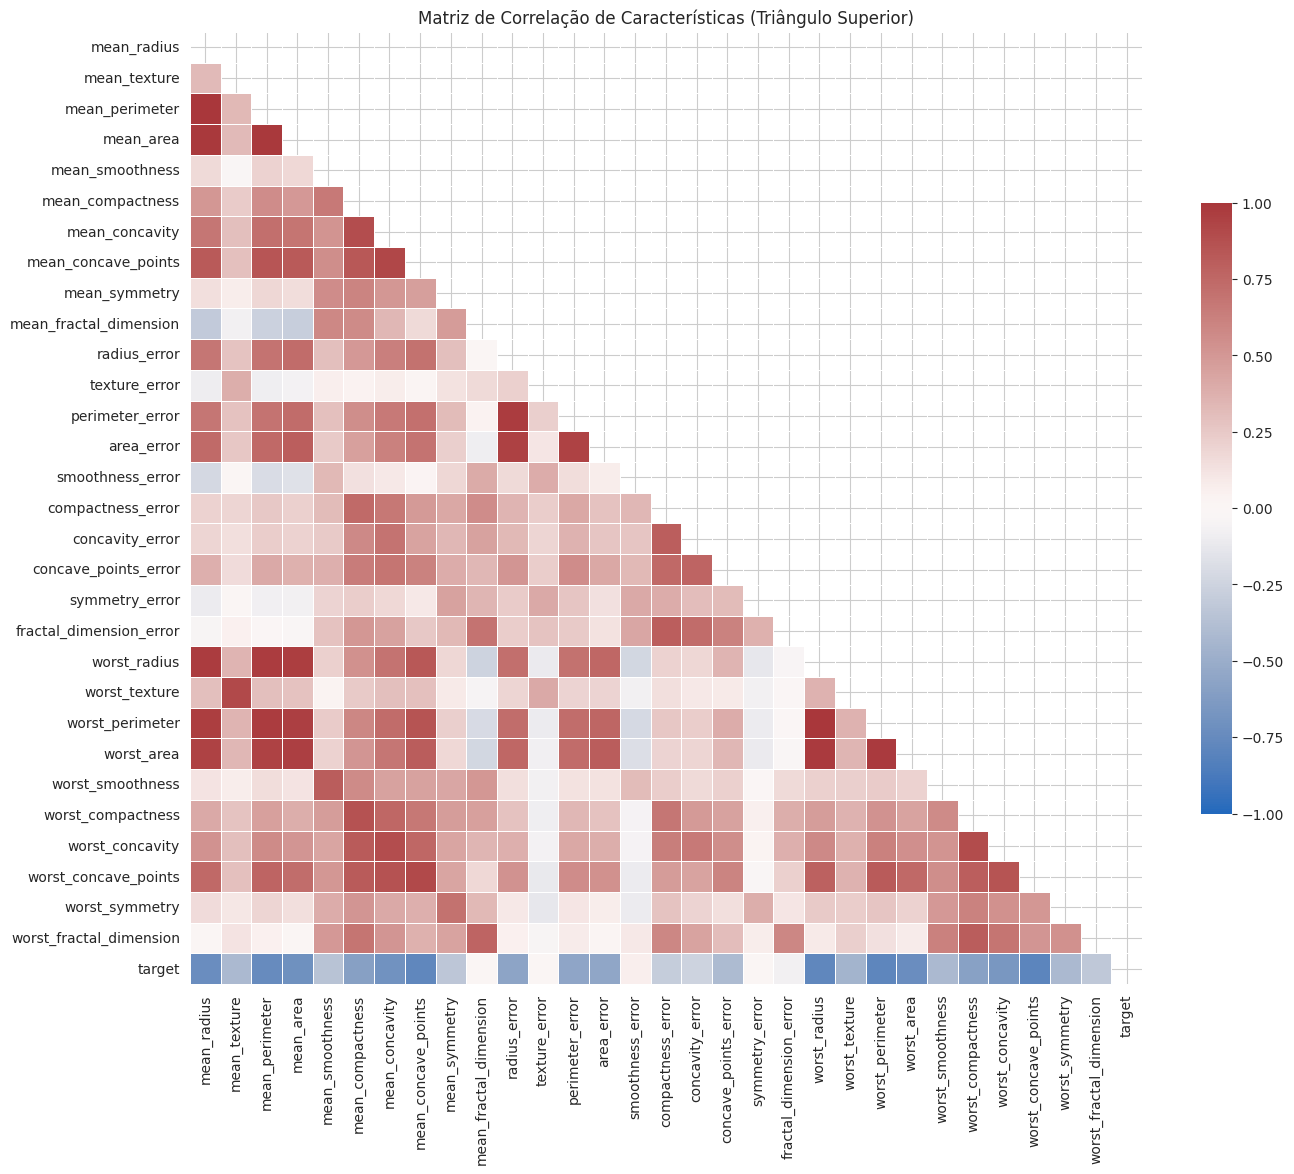

   Top características correlacionadas com target (correlação absoluta):


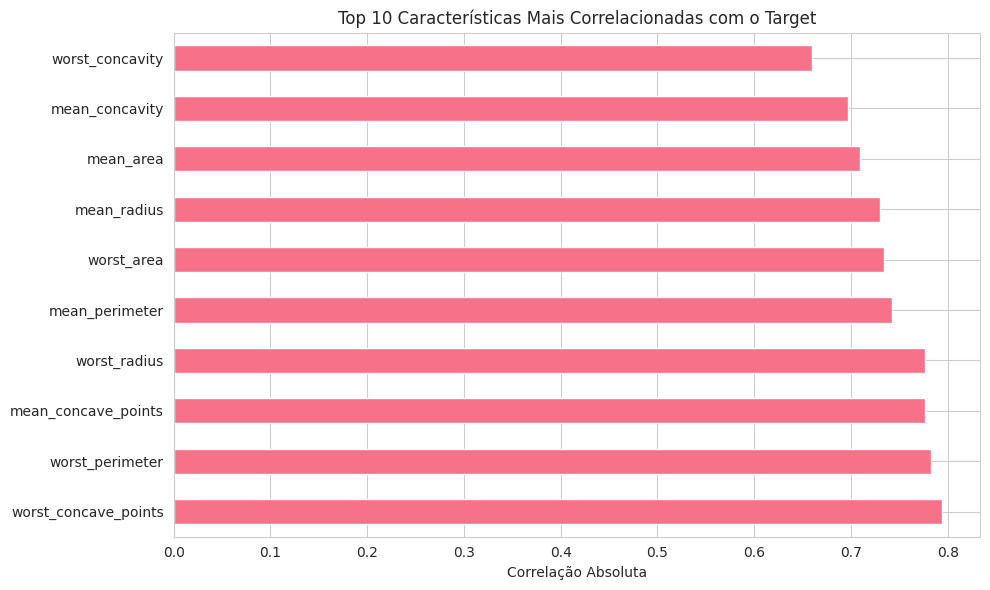

   Visualizando pairplot das características mais importantes


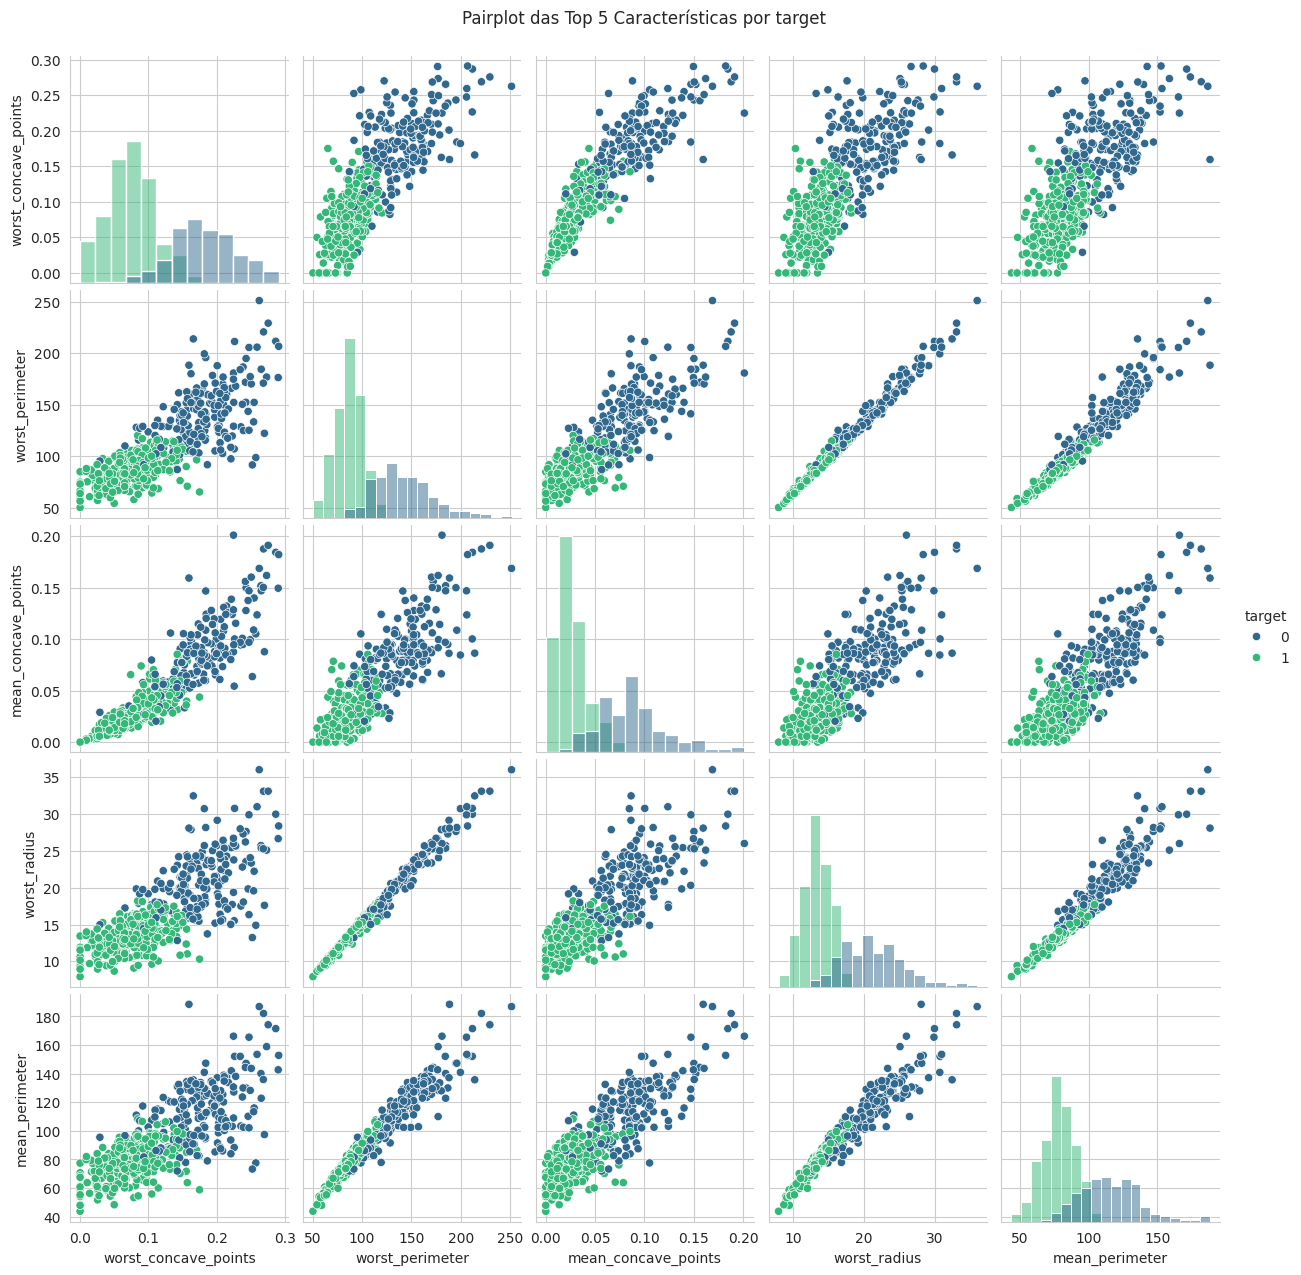

7. Estudando como resolver manualmente com expertise de domínio
   Esboço de solução manual registrado
8. Identificando transformações promissoras
   Transformações sugeridas
9. Identificando dados extras úteis
   Dados adicionais sugeridos: ['demográficos_paciente', 'histórico_familiar', 'marcadores_genéticos', 'metadados de imagem multi-modal']
10. Documentando o que foi aprendido durante a EDA
[DEBUG] Pipeline EDA completo
Descobertas da EDA: {'targetColumn': 'target', 'targetIsCategorical': True, 'targetDistributionSample': {1: 357, 0: 212}, 'topCorrelatedWithTarget': {'worst_concave_points': 0.79356601714127, 'worst_perimeter': 0.7829141371737594, 'mean_concave_points': 0.7766138400204369, 'worst_radius': 0.77645377859504, 'mean_perimeter': 0.7426355297258337, 'worst_area': 0.7338250349210507, 'mean_radius': 0.7300285113754563, 'mean_area': 0.7089838365853907, 'mean_concavity': 0.6963597071719053, 'worst_concavity': 0.6596102103692335}, 'manualSolutionSketch': 'Inspeção especializ

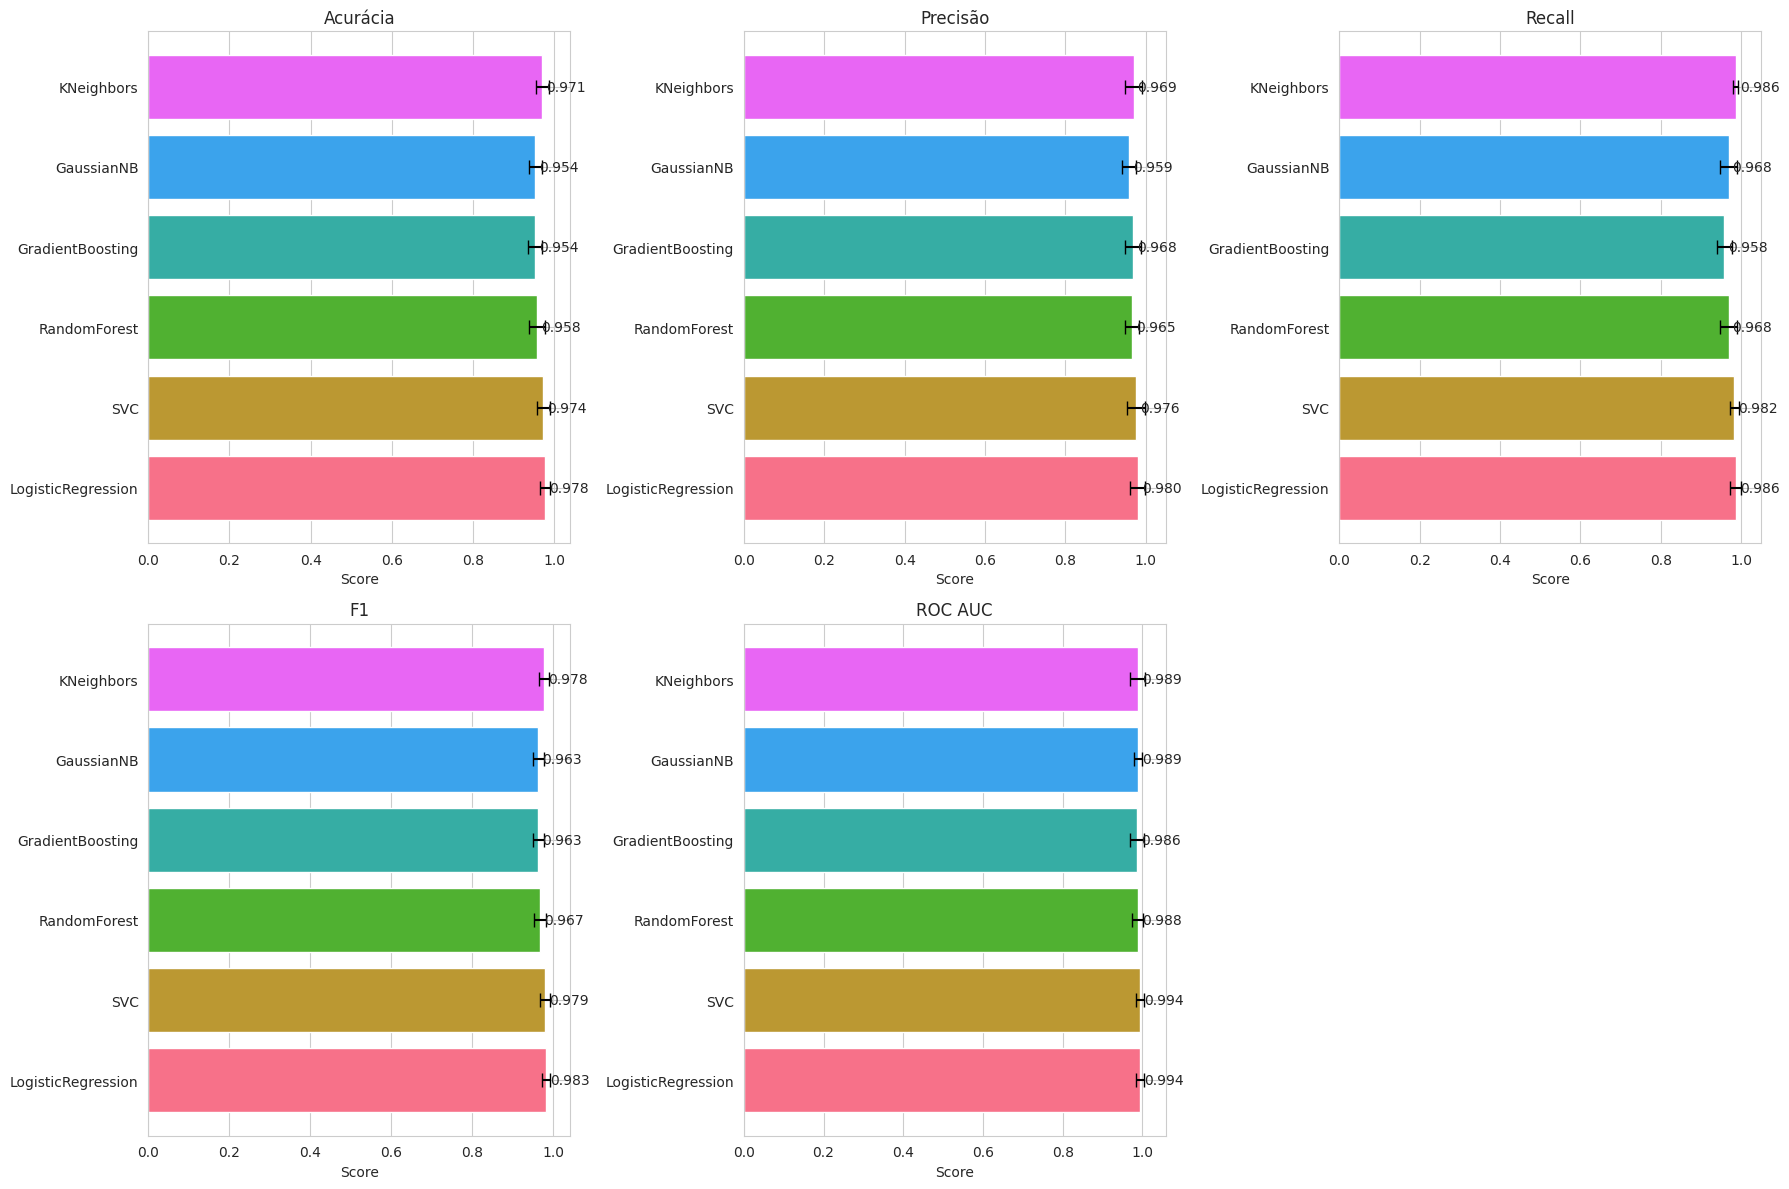

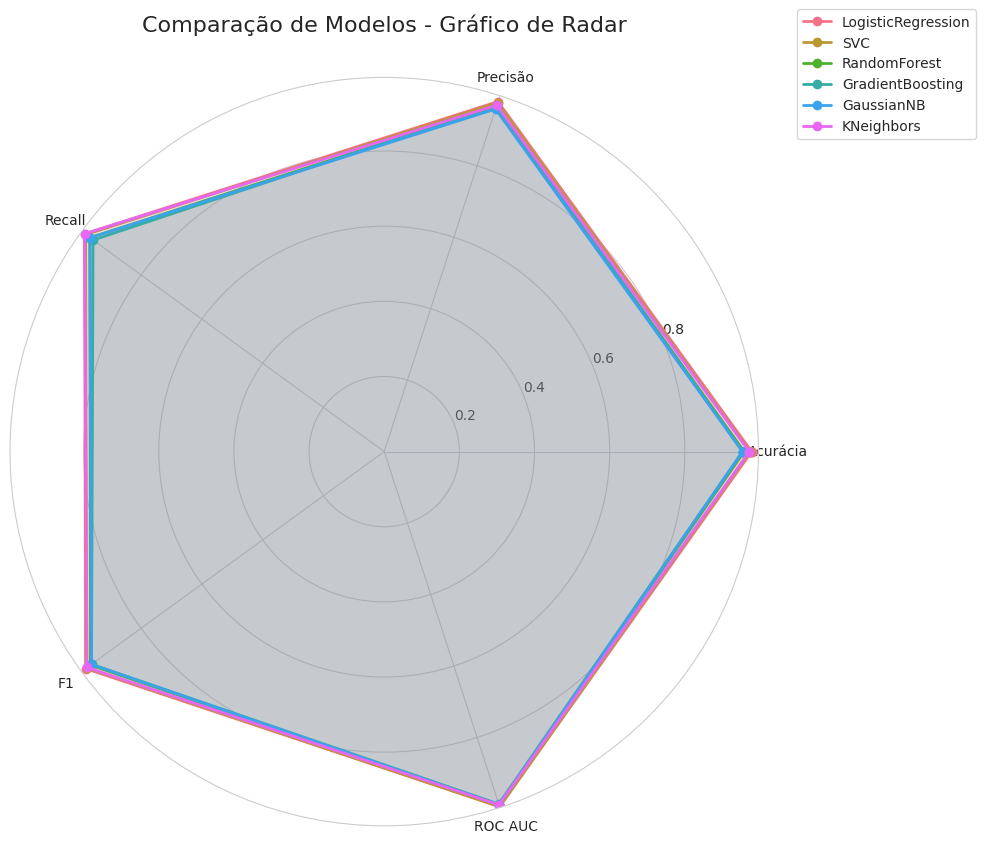


ETAPA 6: AJUSTAR MODELOS
Ajustando hiperparâmetros...
  Ajustando SVC...
    Melhores parâmetros: {'kernel': 'rbf', 'gamma': 'scale', 'C': 10}
    Melhor score: 0.9950
  Ajustando LogisticRegression...
    Melhores parâmetros: {'solver': 'saga', 'penalty': 'l2', 'C': 0.1}
    Melhor score: 0.9944
Criando ensemble...
Avaliando modelo final...
Performance no conjunto de teste:
  accuracy: 0.9825
  precision: 0.9861
  recall: 0.9861
  f1: 0.9861
  roc_auc: 0.9957
Plotando curva ROC...


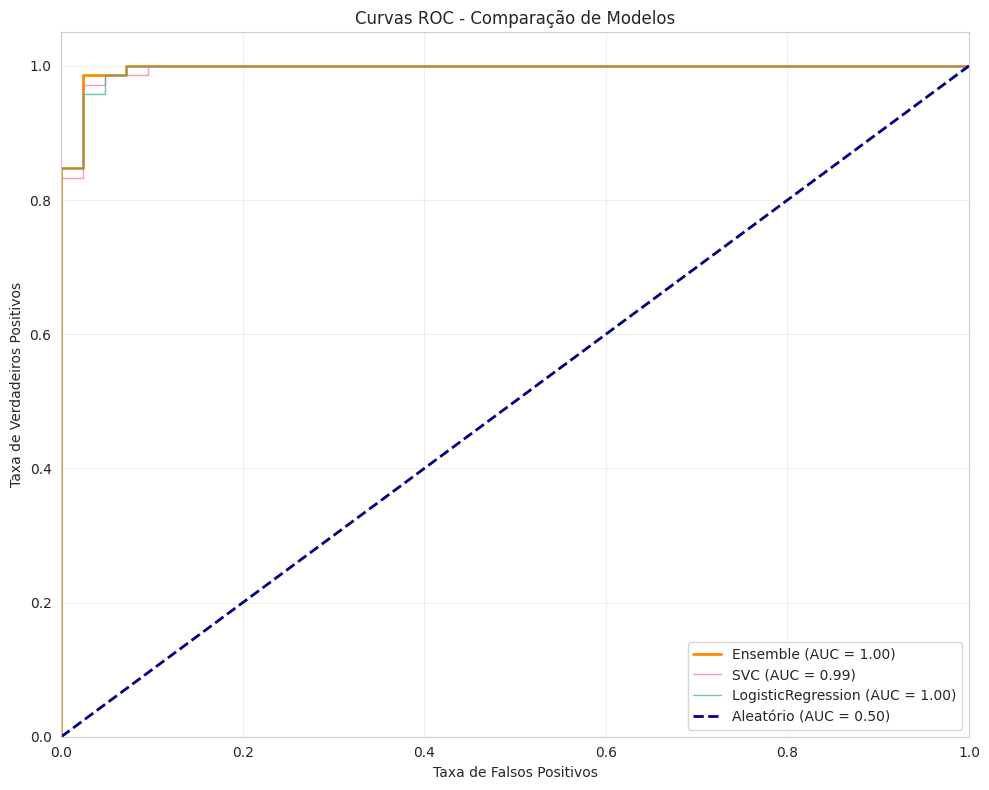

Plotando curva Precision-Recall...


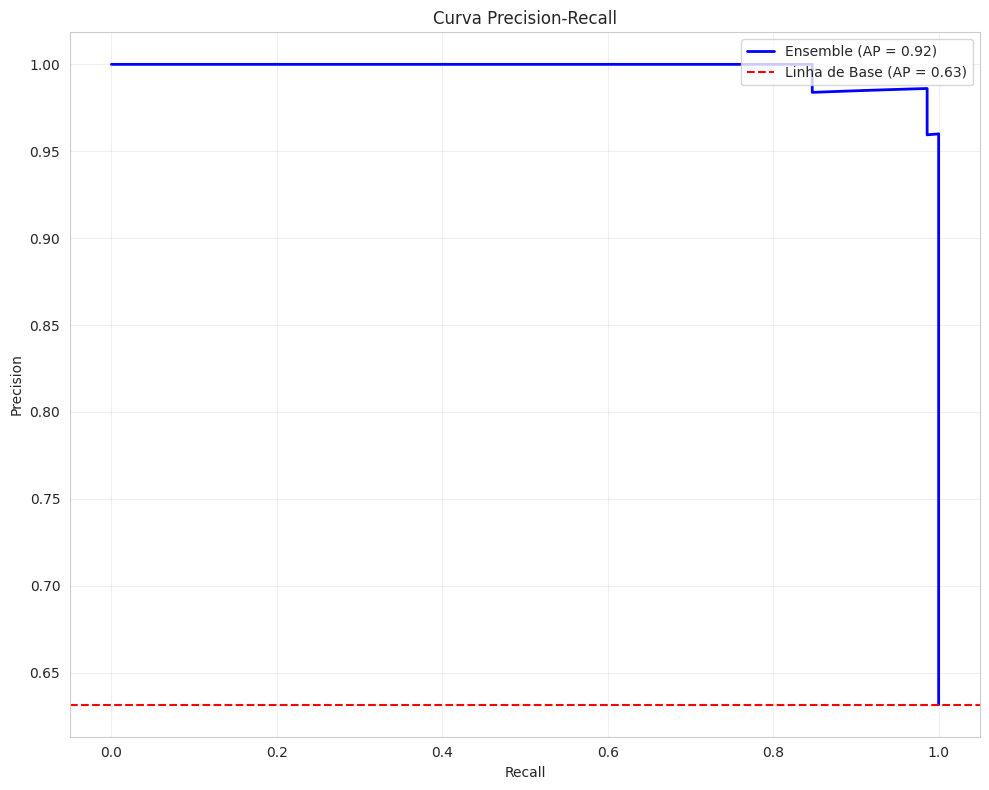

Plotando matriz de confusão...


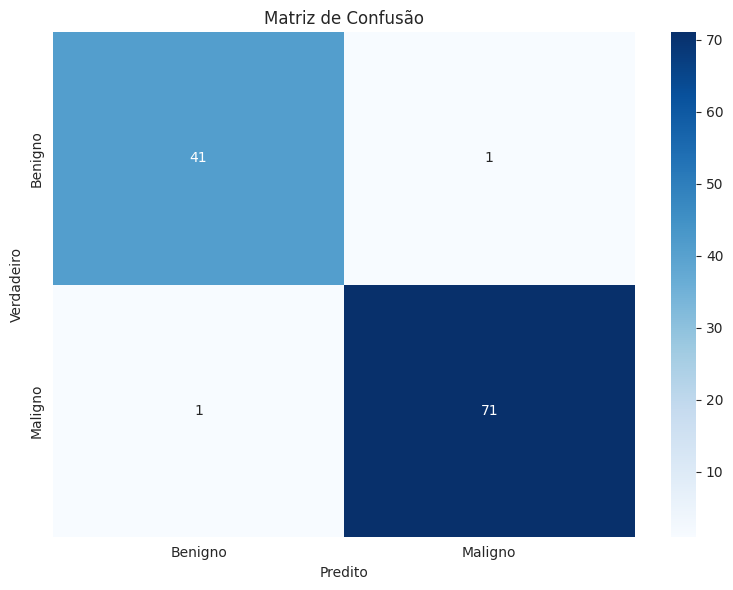

Plotando importância das características...
Nenhum modelo baseado em árvores encontrado para plotar importância.
Plotando curva de aprendizado...


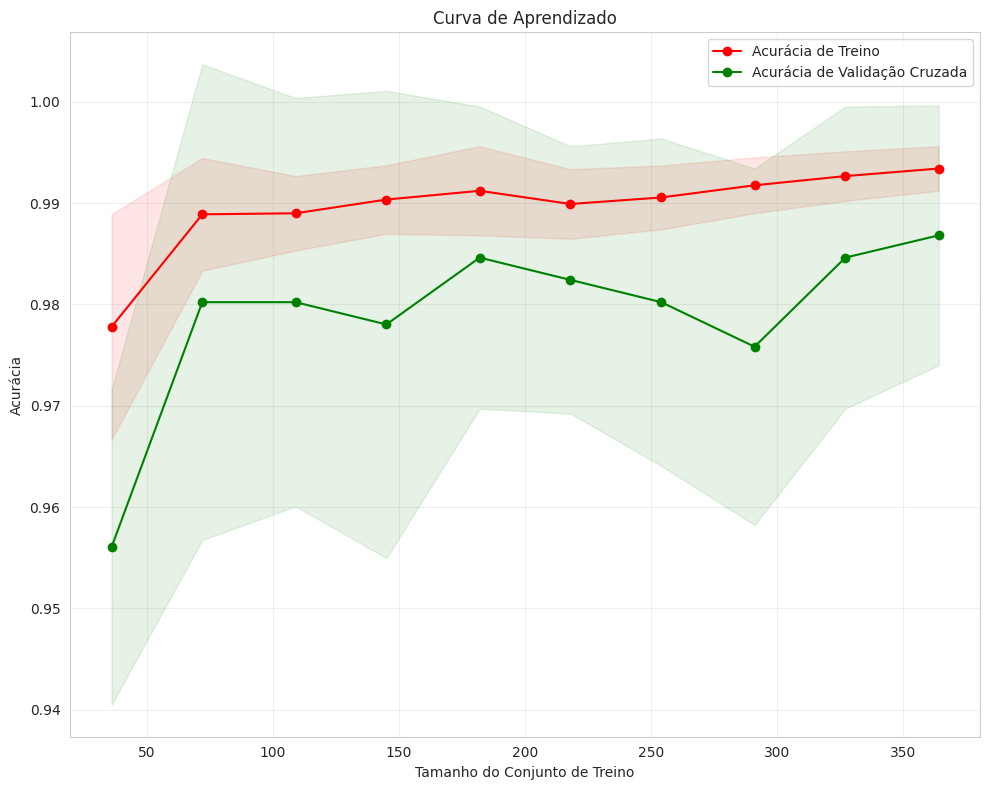


ETAPA 7: APRESENTAR SOLUÇÃO
Salvando relatórios...
Criando resumo executivo...
Criando relatório detalhado...
Relatórios salvos em diretório: reports

PIPELINE CONCLUÍDO COM SUCESSO!


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, learning_curve, validation_curve
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (roc_curve, auc, confusion_matrix, precision_recall_curve,
                             classification_report, RocCurveDisplay, ConfusionMatrixDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_validate, RandomizedSearchCV
from typing import Optional, Dict, Any, List, Tuple
import warnings
warnings.filterwarnings('ignore')

# Configurações globais
RANDOM_STATE = 42
DPI = 300  # Resolução para salvar imagens
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)

class ProblemFramer:
    """
    Classe para enquadrar o problema e entender o panorama geral do projeto.
    """
    def __init__(self, dataset_dataframe: Optional[pd.DataFrame] = None,
                 target_column_name: Optional[str] = None,
                 id_column_name: Optional[str] = None):
        self.dataset_dataframe = dataset_dataframe
        self.target_column_name = target_column_name
        self.id_column_name = id_column_name

        # Funções auxiliares
        self._is_categorical = lambda series: (series.dtype == object) or (series.nunique() <= 30)
        self._safe_div = lambda a, b: a / b if b != 0 else np.nan

    def ingest_dataset(self, dataframe: pd.DataFrame,
                      target_column_name: Optional[str] = None,
                      id_column_name: Optional[str] = None) -> None:
        self.dataset_dataframe = dataframe.copy()
        if target_column_name:
            self.target_column_name = target_column_name
        if id_column_name:
            self.id_column_name = id_column_name

    def summarize_dataset_metadata(self) -> Dict[str, Any]:
        if self.dataset_dataframe is None:
            raise ValueError("Nenhum dataset carregado. Chame ingest_dataset() primeiro.")

        num_rows = len(self.dataset_dataframe)
        num_columns = len(self.dataset_dataframe.columns)
        missing_values = self.dataset_dataframe.isnull().sum().to_dict()
        sample_of_rows = self.dataset_dataframe.head(5)

        id_column_is_unique = None
        if self.id_column_name and self.id_column_name in self.dataset_dataframe.columns:
            id_column_is_unique = self.dataset_dataframe[self.id_column_name].is_unique

        return {
            "numRows": num_rows,
            "numColumns": num_columns,
            "missingValuesByColumn": missing_values,
            "sampleOfRows": sample_of_rows,
            "idColumnIsUnique": id_column_is_unique
        }

    def infer_task_type(self) -> Dict[str, Any]:
        if self.dataset_dataframe is None or self.target_column_name is None:
            return {"inferredTask": "unknown", "isTargetCategorical": None, "classDistribution": None}

        if self.target_column_name not in self.dataset_dataframe.columns:
            raise KeyError(f"Coluna target '{self.target_column_name}' não encontrada no dataset")

        target_series = self.dataset_dataframe[self.target_column_name]
        is_categorical_flag = bool(self._is_categorical(target_series))
        inferred_task = "classification" if is_categorical_flag else "regression"
        result = {"inferredTask": inferred_task, "isTargetCategorical": is_categorical_flag}

        if is_categorical_flag:
            distribution = target_series.value_counts(dropna=False).to_dict()
            class_counts = distribution
            total_count = len(target_series)
            class_proportions = {k: (v, round(self._safe_div(v, total_count), 4))
                                for k, v in class_counts.items()}
            result["classDistribution"] = class_proportions

        return result

    def propose_performance_metrics(self) -> Dict[str, str]:
        inferred = self.infer_task_type().get("inferredTask", "unknown")

        if inferred == "classification":
            primary_metric = "roc_auc"
            secondary_metric = "f1_score"
            rationale_text = "Use ROC AUC para separabilidade geral e F1 para balanceamento de classes e trade-offs operacionais."
        elif inferred == "regression":
            primary_metric = "root_mean_squared_error"
            secondary_metric = "mean_absolute_error"
            rationale_text = "Use RMSE para penalizar grandes erros e MAE para erro médio interpretável."
        elif inferred == "unknown":
            primary_metric = "tbd"
            secondary_metric = "tbd"
            rationale_text = "Incapaz de inferir tarefa: forneça coluna target ou especifique tipo de tarefa."
        else:
            primary_metric = "tbd"
            secondary_metric = "tbd"
            rationale_text = "Para clustering considere silhouette_score e adjusted_mutual_info_score se existir ground truth."

        return {
            "recommendedPrimaryMetric": primary_metric,
            "recommendedSecondaryMetric": secondary_metric,
            "rationale": rationale_text
        }

    def suggest_minimum_acceptable_performance(self,
                                              baseline_performance_value: Optional[float] = None) -> Dict[str, Any]:
        inferred = self.infer_task_type().get("inferredTask", "unknown")

        if baseline_performance_value is None:
            suggestion = None
            explanation = "Nenhuma baseline fornecida; por favor forneça performance existente ou target de negócio para sugerir mínimo."
        else:
            if inferred == "classification":
                suggested_minimum = round(min(0.99, baseline_performance_value * 1.02), 4)
                suggestion = suggested_minimum
                explanation = "Sugiro melhorar a baseline atual em ~2% relativo quando viável."
            elif inferred == "regression":
                suggested_minimum = round(max(0.0, baseline_performance_value * 0.98), 4)
                suggestion = suggested_minimum
                explanation = "Sugiro diminuir RMSE em ~2% relativo quando viável."
            else:
                suggestion = None
                explanation = "Tarefa desconhecida; não posso propor mínimo numérico automaticamente."

        return {"suggestedMinimum": suggestion, "explanation": explanation}

    def list_checklist_items_not_applicable(self, custom_notes: Optional[str] = None) -> Dict[str, Any]:
        note_text = custom_notes if custom_notes else "Nenhuma exceção registrada."
        return {"justifications": note_text}


class DataManager:
    """
    Gerencia a aquisição e preparação inicial dos dados.
    """
    def __init__(self, workspace_directory_path: str = "wdbc_workspace",
                 preferred_kaggle_dataset_slug: str = "uciml/breast-cancer-wisconsin-data",
                 desired_test_ratio: float = 0.2,
                 random_state: int = RANDOM_STATE):
        self.workspace_directory_path = Path(workspace_directory_path)
        self.raw_data_directory_path = self.workspace_directory_path / "raw"
        self.processed_data_directory_path = self.workspace_directory_path / "processed"
        self.preferred_kaggle_dataset_slug = preferred_kaggle_dataset_slug
        self.desired_test_ratio = desired_test_ratio
        self.random_state = random_state

        # Outputs a serem preenchidos
        self.dataFrame: Optional[pd.DataFrame] = None
        self.target_variable: Optional[str] = None
        self.X_train: Optional[pd.DataFrame] = None
        self.X_test: Optional[pd.DataFrame] = None
        self.y_train: Optional[pd.Series] = None
        self.y_test: Optional[pd.Series] = None

        # Funções auxiliares
        self._is_csv = lambda filename: str(filename).lower().endswith(".csv")
        self._make_path = lambda p: Path(p)
        self._ensure_dir = lambda p: Path(p).mkdir(parents=True, exist_ok=True)

    def _ensure_workspace(self) -> None:
        for directory in (self.workspace_directory_path, self.raw_data_directory_path, self.processed_data_directory_path):
            self._ensure_dir(directory)

    def _fallback_load_from_sklearn(self) -> pd.DataFrame:
        payload = load_breast_cancer()
        df = pd.DataFrame(payload.data, columns=[c.replace(" ", "_") for c in payload.feature_names])
        df["target"] = payload.target
        return df

    def _identify_and_set_target(self, dataframe: pd.DataFrame,
                                potential_targets: Optional[List[str]] = None) -> str:
        potential_targets = potential_targets or ['target', 'diagnosis', 'class', 'outcome']
        for candidate in potential_targets:
            if candidate in dataframe.columns:
                return candidate
        fallback = dataframe.columns[-1]
        return fallback

    def _encode_target_if_needed(self, y_series: pd.Series) -> pd.Series:
        if y_series.dtype == object or y_series.dtype.name == "category":
            unique_vals = y_series.unique()
            mapping = {v: i for i, v in enumerate(sorted(unique_vals))}
            return y_series.map(lambda v: mapping[v]).astype(int)
        return y_series

    def get_data(self) -> None:
        print("1. Listando os dados que você precisa e quanto você precisa.")
        print("   Necessário: Dados de diagnóstico de câncer de mama com 30 características numéricas computadas de imagens FNA. Necessário pelo menos várias centenas de amostras para validação cruzada robusta.")

        print("\n2. Encontrando e documentando onde você pode obter esses dados.")
        print(f"   Fonte preferida: Dataset Kaggle slug: {self.preferred_kaggle_dataset_slug}")

        print("\n3. Verificando quanto espaço vai ocupar.")
        print("   Tamanho esperado: muito pequeno (dezenas a centenas de KB). Sobrecarga de armazenamento negligenciável.")

        print("\n4. Verificando obrigações legais e obtendo autorização se necessário.")
        print("   Dataset tipicamente sob CC BY 4.0 (cópias UCI/Kaggle). Reveja licença se redistribuindo ou comercializando.")

        print("\n5. Obtendo autorizações de accesso.")
        print("   Método de acesso: kagglehub (não precisa de kaggle.json). Se usando API oficial Kaggle, garanta kaggle.json presente ou env vars configuradas.")

        print("\n6. Criando workspace (com espaço de armazenamento suficiente).")
        self._ensure_workspace()

        print("\n7. Obtendo os dados.")
        try:
            self.dataFrame = self._fallback_load_from_sklearn()
            print("   Dataset carregado do sklearn (load_breast_cancer)...")
        except Exception as e:
            print(f"   Erro no download: {e}")
            print("   Carregando dataset de fallback do sklearn...")
            self.dataFrame = self._fallback_load_from_sklearn()

        print("\n8. Convertendo os dados para um formato que você pode manipular facilmente (sem mudar os dados em si).")
        print("   Usando pandas DataFrame como representação canônica em memória.")

        print("\n9. Garantindo que informações sensíveis sejam deletadas ou protegidas (ex: anonimizadas).")
        # WDBC não tem PII, mas demonstra API

        print("\n10. Verificando o tamanho e tipo dos dados (série temporal, amostra, geográfica, etc.).")
        rows_count, cols_count = self.dataFrame.shape
        print(f"   Tipo de dados: Tabular. Amostras: {rows_count}, Características (incluindo target se presente): {cols_count}")

        print("\n11. Amostrando um conjunto de teste, colocando de lado e nunca olhando (sem data snooping!).")
        self.target_variable = self._identify_and_set_target(self.dataFrame)
        X = self.dataFrame.drop(columns=[self.target_variable])
        y = self.dataFrame[self.target_variable]

        y_encoded = self._encode_target_if_needed(y)

        is_classification = True if y_encoded.nunique() <= 20 and y_encoded.dtype in [np.int64, np.int32, np.int16, np.int8] else False
        stratify_arg = y_encoded if is_classification else None

        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y_encoded, test_size=self.desired_test_ratio,
            random_state=self.random_state, stratify=stratify_arg)

        print(f"   Conjunto de teste criado com {len(self.y_test)} amostras ({int(self.desired_test_ratio*100)}% do total).")


class ExploratoryAnalyzer:
    """
    Realiza análise exploratória completa em um pandas DataFrame.
    """
    def __init__(self, dataset_dataframe: pd.DataFrame,
                 target_column_name: Optional[str] = None,
                 sample_max_rows: int = 1000,
                 random_state: int = RANDOM_STATE):
        self.dataset_dataframe = dataset_dataframe
        self.target_column_name = target_column_name
        self.sample_max_rows = sample_max_rows
        self.random_state = random_state
        self.findings_summary: Dict[str, Any] = {}

        # Funções auxiliares
        self._is_categorical = lambda series: (series.dtype == object) or (series.nunique() <= 30)
        self._safe_div = lambda a, b: a / b if b != 0 else np.nan
        self._sample_df = lambda df: df.sample(n=min(len(df), self.sample_max_rows),
                                              random_state=self.random_state)

    def create_exploration_copy(self) -> pd.DataFrame:
        df_copy = self.dataset_dataframe.copy()
        if len(df_copy) > self.sample_max_rows:
            print(f"   Dataset grande ({len(df_copy)} linhas), amostrando até {self.sample_max_rows} linhas para EDA interativa")
            df_copy = self._sample_df(df_copy)
        else:
            print("   Dataset em tamanho manejável; usando cópia completa para exploração")
        print(f"   Cópia criada com shape: {df_copy.shape}")
        return df_copy

    def summarize_schema_and_missing(self, df_explore: pd.DataFrame) -> pd.DataFrame:
        print("3. Estudando cada atributo: nome, tipo, % missing, ruído estimado, utilidade preliminar")
        col_names = []
        col_types = []
        missing_counts = []
        missing_pcts = []
        unique_counts = []

        for col in df_explore.columns:
            col_names.append(col)
            col_types.append(str(df_explore[col].dtype))
            missing_count = int(df_explore[col].isnull().sum())
            missing_counts.append(missing_count)
            missing_pcts.append(round(self._safe_div(missing_count, len(df_explore)) * 100, 3))
            unique_counts.append(int(df_explore[col].nunique(dropna=True)))

        schema_df = pd.DataFrame({
            "name": col_names,
            "dtype": col_types,
            "missing_count": missing_counts,
            "missing_pct": missing_pcts,
            "unique_count": unique_counts
        }).sort_values(by="missing_pct", ascending=False).reset_index(drop=True)

        return schema_df

    def describe_numeric_and_categorical(self, df_explore: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
        print("   Estatísticas descritivas para atributos numéricos e categóricos")
        numeric_df = df_explore.select_dtypes(include=[np.number])
        categorical_df = df_explore.select_dtypes(exclude=[np.number])

        num_desc = numeric_df.describe().T
        cat_desc = categorical_df.describe().T if not categorical_df.empty else pd.DataFrame()

        return num_desc, cat_desc

    def identify_target_and_distribution(self, df_explore: pd.DataFrame) -> Dict[str, Any]:
        print("4. Identificando o(s) atributo(s) alvo para tarefas supervisionadas")
        if self.target_column_name and self.target_column_name in df_explore.columns:
            chosen_target = self.target_column_name
            print(f"   Target informado: {chosen_target}")
        else:
            candidates = ['target', 'diagnosis', 'class', 'outcome']
            chosen_target = next((c for c in candidates if c in df_explore.columns), df_explore.columns[-1])
            print(f"   Target inferido: {chosen_target}")

        target_series = df_explore[chosen_target]
        is_categorical_flag = self._is_categorical(target_series)
        distribution_info = None

        if is_categorical_flag:
            value_counts = target_series.value_counts(dropna=False)
            distribution_info = value_counts.to_dict()
            print(f"   Target categórico detectado com distribuição: {distribution_info}")

            # Gráfico de pizza para distribuição de classes
            plt.figure(figsize=(8, 6))
            value_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90)
            plt.title("Distribuição da Variável Target")
            plt.ylabel('')
            plt.tight_layout()
            plt.savefig("target_distribution_pie.png", dpi=DPI, bbox_inches='tight')
            plt.show()

        else:
            distribution_info = target_series.describe().to_dict()
            print(f"   Target numérico detectado com estatísticas: {distribution_info}")

        self.findings_summary["targetColumn"] = chosen_target
        self.findings_summary["targetIsCategorical"] = is_categorical_flag
        self.findings_summary["targetDistributionSample"] = distribution_info

        # Visualização
        print("   Visualizando distribuição do target")
        plt.figure(figsize=(10, 6))
        if is_categorical_flag:
            # Gráfico de barras
            ax = sns.countplot(x=chosen_target, data=df_explore)
            plt.title("Distribuição da Variável Target")

            # Adicionar valores nas barras
            for p in ax.patches:
                ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                          ha='center', va='bottom', fontsize=10)
        else:
            # Histograma com KDE
            sns.histplot(target_series, kde=True)
            plt.title("Distribuição da Variável Target (numérica)")

            # Adicionar linhas para média e mediana
            plt.axvline(target_series.mean(), color='r', linestyle='--', label=f'Média: {target_series.mean():.2f}')
            plt.axvline(target_series.median(), color='g', linestyle='--', label=f'Mediana: {target_series.median():.2f}')
            plt.legend()

        plt.tight_layout()
        plt.savefig("target_distribution.png", dpi=DPI, bbox_inches='tight')
        plt.show()

        return {
            "targetColumn": chosen_target,
            "isCategorical": is_categorical_flag,
            "distribution": distribution_info
        }

    def plot_numeric_feature_distributions(self, df_explore: pd.DataFrame,
                                          exclude_columns: Optional[List[str]] = None) -> None:
        print("5. Visualizando atributos numéricos (histogramas + KDE)")
        exclude = set(exclude_columns or [])
        numeric_cols = [c for c in df_explore.select_dtypes(include=[np.number]).columns
                       if c not in exclude]

        if not numeric_cols:
            print("   Sem atributos numéricos para plotar")
            return

        # Calcular número de linhas e colunas para subplots
        n_cols = 3
        n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
        axes = axes.flatten()

        for i, feature in enumerate(numeric_cols):
            sns.histplot(df_explore[feature].dropna(), kde=True, ax=axes[i])
            axes[i].set_title(f"Distribuição de {feature}")

            # Adicionar linhas para média e mediana
            mean_val = df_explore[feature].mean()
            median_val = df_explore[feature].median()
            axes[i].axvline(mean_val, color='r', linestyle='--', label=f'Média: {mean_val:.2f}')
            axes[i].axvline(median_val, color='g', linestyle='--', label=f'Mediana: {median_val:.2f}')
            axes[i].legend()

        # Ocultar eixos vazios
        for j in range(i+1, len(axes)):
            axes[j].set_visible(False)

        plt.tight_layout()
        plt.savefig("numeric_features_distributions.png", dpi=DPI, bbox_inches='tight')
        plt.show()

    def plot_boxplots_by_target(self, df_explore: pd.DataFrame, top_n: int = 10) -> None:
        print("   Visualizando boxplots das características por target")
        target_col = self.findings_summary.get("targetColumn")
        if not target_col or target_col not in df_explore.columns:
            print("   Target não encontrado para boxplots")
            return

        numeric_cols = df_explore.select_dtypes(include=[np.number]).columns
        numeric_cols = [c for c in numeric_cols if c != target_col]

        # Selecionar apenas as top N características mais correlacionadas com o target
        if len(numeric_cols) > top_n:
            # Calcular correlações
            corr_with_target = df_explore[numeric_cols].corrwith(df_explore[target_col]).abs()
            top_features = corr_with_target.nlargest(top_n).index.tolist()
        else:
            top_features = numeric_cols

        n_cols = 3
        n_rows = (len(top_features) + n_cols - 1) // n_cols

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
        axes = axes.flatten()

        for i, feature in enumerate(top_features):
            sns.boxplot(x=target_col, y=feature, data=df_explore, ax=axes[i])
            axes[i].set_title(f"{feature} por {target_col}")

        # Ocultar eixos vazios
        for j in range(i+1, len(axes)):
            axes[j].set_visible(False)

        plt.tight_layout()
        plt.savefig("boxplots_by_target.png", dpi=DPI, bbox_inches='tight')
        plt.show()

    def compute_and_plot_correlations(self, df_explore: pd.DataFrame,
                                    annotate_top_k: int = 10) -> pd.DataFrame:
        print("6. Estudando correlações entre atributos")
        df_numeric = df_explore.select_dtypes(include=[np.number]).copy()
        target = self.findings_summary.get("targetColumn", None)

        if target and target not in df_numeric.columns and target in df_explore.columns:
            print("   Target não numérico presente: codificando temporariamente para correlação")
            encoded = LabelEncoder().fit_transform(df_explore[target].astype(str))
            df_numeric[target] = encoded

        corr_matrix = df_numeric.corr()

        # Plotar heatmap de correlação
        plt.figure(figsize=(14, 12))
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Máscara para o triângulo superior
        sns.heatmap(corr_matrix, mask=mask, vmax=1.0, vmin=-1.0, cmap="vlag",
                   square=True, linewidths=.5, cbar_kws={"shrink": .6}, annot=False)
        plt.title("Matriz de Correlação de Características (Triângulo Superior)")
        plt.tight_layout()
        plt.savefig("correlation_matrix.png", dpi=DPI, bbox_inches='tight')
        plt.show()

        if target and target in corr_matrix.columns:
            abs_sorted = corr_matrix[target].abs().sort_values(ascending=False)
            top_correlated = abs_sorted.drop(labels=[target]).head(annotate_top_k)
            print("   Top características correlacionadas com target (correlação absoluta):")
            self.findings_summary["topCorrelatedWithTarget"] = top_correlated.to_dict()

            # Plotar as top características correlacionadas com o target
            plt.figure(figsize=(10, 6))
            top_correlated.plot(kind='barh')
            plt.title(f"Top {annotate_top_k} Características Mais Correlacionadas com o Target")
            plt.xlabel("Correlação Absoluta")
            plt.tight_layout()
            plt.savefig("top_correlated_features.png", dpi=DPI, bbox_inches='tight')
            plt.show()

        return corr_matrix

    def plot_pairplot_top_features(self, df_explore: pd.DataFrame, top_n: int = 5) -> None:
        print("   Visualizando pairplot das características mais importantes")
        target_col = self.findings_summary.get("targetColumn")
        if not target_col or target_col not in df_explore.columns:
            print("   Target não encontrado para pairplot")
            return

        numeric_cols = df_explore.select_dtypes(include=[np.number]).columns
        numeric_cols = [c for c in numeric_cols if c != target_col]

        # Selecionar apenas as top N características mais correlacionadas com o target
        if len(numeric_cols) > top_n:
            # Calcular correlações
            corr_with_target = df_explore[numeric_cols].corrwith(df_explore[target_col]).abs()
            top_features = corr_with_target.nlargest(top_n).index.tolist()
        else:
            top_features = numeric_cols

        # Adicionar o target às características para o pairplot
        plot_features = top_features + [target_col]

        # Samplear os dados se forem muitos
        plot_df = df_explore[plot_features]
        if len(plot_df) > 500:
            plot_df = plot_df.sample(n=500, random_state=self.random_state)

        # Plotar pairplot
        sns.pairplot(plot_df, hue=target_col, diag_kind='hist', palette='viridis')
        plt.suptitle(f"Pairplot das Top {top_n} Características por {target_col}", y=1.02)
        plt.savefig("pairplot_top_features.png", dpi=DPI, bbox_inches='tight')
        plt.show()

    def manual_problem_solving_notes(self) -> str:
        print("7. Estudando como resolver manualmente com expertise de domínio")
        note = ("Inspeção especializada de padrões de raio, textura, perímetro e concavidade do núcleo "
                "para sinalizar malignidade; combinar thresholds em múltiplas características para decisões baseadas em regras simples.")
        print("   Esboço de solução manual registrado")
        self.findings_summary["manualSolutionSketch"] = note
        return note

    def propose_transformations_and_actions(self) -> Dict[str, Any]:
        print("8. Identificando transformações promissoras")
        suggestions = {
            "standardization": "StandardScaler para características numéricas",
            "log_transform": "Considerar transformação log para características enviesadas (área, perímetro)",
            "pca": "PCA para redução de dimensionalidade ou visualização se muitas características correlacionadas",
            "encoding": "LabelEncoder para target e OneHot se novas características categóricas aparecerem",
            "classImbalanceHandling": "SMOTE ou perdas ponderadas por classe se desbalanceamento detectado"
        }
        print("   Transformações sugeridas")
        self.findings_summary["transformations"] = suggestions
        return suggestions

    def suggest_additional_data(self) -> List[str]:
        print("9. Identificando dados extras úteis")
        extras = ["demográficos_paciente", "histórico_familiar", "marcadores_genéticos",
                 "metadados de imagem multi-modal"]
        print(f"   Dados adicionais sugeridos: {extras}")
        self.findings_summary["additionalDataSuggestions"] = extras
        return extras

    def document_findings(self) -> Dict[str, Any]:
        print("10. Documentando o que foi aprendido durante a EDA")
        self.findings_summary.setdefault("notes", "EDA completada; consulte chaves de descobertas para detalhes")
        return self.findings_summary

    def explore_data(self) -> Dict[str, Any]:
        df_for_exploration = self.create_exploration_copy()
        schema_summary = self.summarize_schema_and_missing(df_for_exploration)
        numeric_desc, categorical_desc = self.describe_numeric_and_categorical(df_for_exploration)
        target_info = self.identify_target_and_distribution(df_for_exploration)

        # Excluir colunas tipo id de plots e correlação
        exclude_columns = [c for c in df_for_exploration.columns if c.lower() == "id"]
        self.plot_numeric_feature_distributions(df_for_exploration,
                                              exclude_columns=exclude_columns + [target_info["targetColumn"]])

        self.plot_boxplots_by_target(df_for_exploration, top_n=10)
        corr_matrix = self.compute_and_plot_correlations(df_for_exploration)
        self.plot_pairplot_top_features(df_for_exploration, top_n=5)
        self.manual_problem_solving_notes()
        self.propose_transformations_and_actions()
        self.suggest_additional_data()
        findings = self.document_findings()

        print("[DEBUG] Pipeline EDA completo")
        return findings


class DataPreparer:
    """
    Prepara os dados para melhor expor padrões subjacentes aos algoritmos de ML.
    """
    def __init__(self, X_train: pd.DataFrame, X_test: pd.DataFrame,
                 y_train: pd.Series, y_test: pd.Series,
                 target_variable: str):
        self.X_train = X_train.copy()
        self.X_test = X_test.copy()
        self.y_train = y_train.copy()
        self.y_test = y_test.copy()
        self.target_variable = target_variable

    def handle_missing_values(self, strategy: str = "median") -> None:
        print("Lidando com valores ausentes...")

        if strategy == "drop":
            self.X_train.dropna(inplace=True)
            self.X_test.dropna(inplace=True)
            self.y_train = self.y_train.loc[self.X_train.index]
            self.y_test = self.y_test.loc[self.X_test.index]
        else:
            for col in self.X_train.columns:
                if self.X_train[col].isnull().any():
                    if strategy == "median" and self.X_train[col].dtype in [np.int64, np.float64]:
                        fill_value = self.X_train[col].median()
                    elif strategy == "mean" and self.X_train[col].dtype in [np.int64, np.float64]:
                        fill_value = self.X_train[col].mean()
                    elif strategy == "mode":
                        fill_value = self.X_train[col].mode()[0]
                    else:
                        fill_value = 0

                    self.X_train[col].fillna(fill_value, inplace=True)
                    self.X_test[col].fillna(fill_value, inplace=True)

    def feature_engineering(self) -> None:
        print("Realizando engenharia de características...")

        radius_cols = [col for col in self.X_train.columns if 'radius' in col.lower()]
        texture_cols = [col for col in self.X_train.columns if 'texture' in col.lower()]
        perimeter_cols = [col for col in self.X_train.columns if 'perimeter' in col.lower()]
        area_cols = [col for col in self.X_train.columns if 'area' in col.lower()]

        for i, area_col in enumerate(area_cols):
            if i < len(radius_cols):
                ratio_name = f"area_radius_ratio_{i}"
                self.X_train[ratio_name] = self.X_train[area_col] / self.X_train[radius_cols[i]]
                self.X_test[ratio_name] = self.X_test[area_col] / self.X_test[radius_cols[i]]

        for i, perimeter_col in enumerate(perimeter_cols):
            if i < len(area_cols):
                ratio_name = f"perimeter_area_ratio_{i}"
                self.X_train[ratio_name] = self.X_train[perimeter_col] / self.X_train[area_cols[i]]
                self.X_test[ratio_name] = self.X_test[perimeter_col] / self.X_test[area_cols[i]]

    def scale_features(self, method: str = "standard") -> None:
        print("Escalonando características...")

        from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

        if method == "standard":
            scaler = StandardScaler()
        elif method == "minmax":
            scaler = MinMaxScaler()
        elif method == "robust":
            scaler = RobustScaler()
        else:
            scaler = StandardScaler()

        self.X_train = pd.DataFrame(scaler.fit_transform(self.X_train),
                                   columns=self.X_train.columns,
                                   index=self.X_train.index)

        self.X_test = pd.DataFrame(scaler.transform(self.X_test),
                                  columns=self.X_test.columns,
                                  index=self.X_test.index)

    def prepare_data(self, missing_strategy: str = "median",
                    scale_method: str = "standard") -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
        print("Iniciando preparação de dados...")

        self.handle_missing_values(strategy=missing_strategy)
        self.feature_engineering()
        self.scale_features(method=scale_method)

        print("Preparação de dados completa!")
        return self.X_train, self.X_test, self.y_train, self.y_test


class ModelSelector:
    """
    Seleciona modelos promissores usando validação cruzada.
    """
    def __init__(self, X_train: pd.DataFrame, y_train: pd.Series,
                 random_state: int = RANDOM_STATE):
        self.X_train = X_train
        self.y_train = y_train
        self.random_state = random_state
        self.models_performance = {}

    def train_models(self, cv_folds: int = 5) -> Dict[str, Any]:
        print("Treinando modelos...")

        from sklearn.model_selection import cross_validate

        models = {
            "LogisticRegression": LogisticRegression(random_state=self.random_state, max_iter=1000),
            "SVC": SVC(random_state=self.random_state, probability=True),
            "RandomForest": RandomForestClassifier(random_state=self.random_state),
            "GradientBoosting": GradientBoostingClassifier(random_state=self.random_state),
            "GaussianNB": GaussianNB(),
            "KNeighbors": KNeighborsClassifier()
        }

        scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

        for name, model in models.items():
            print(f"  Avaliando {name}...")
            cv_results = cross_validate(model, self.X_train, self.y_train,
                                      cv=cv_folds, scoring=scoring, n_jobs=-1)

            model_results = {}
            for metric in scoring:
                mean_key = f"mean_{metric}"
                std_key = f"std_{metric}"
                model_results[mean_key] = np.mean(cv_results[f"test_{metric}"])
                model_results[std_key] = np.std(cv_results[f"test_{metric}"])

            self.models_performance[name] = model_results

        return self.models_performance

    def select_best_models(self, top_n: int = 3, primary_metric: str = "mean_roc_auc") -> List[str]:
        print("Selecionando melhores modelos...")

        sorted_models = sorted(self.models_performance.items(),
                              key=lambda x: x[1][primary_metric],
                              reverse=True)

        best_models = [model[0] for model in sorted_models[:top_n]]

        print(f"Melhores modelos ({primary_metric}):")
        for i, (model_name, metrics) in enumerate(sorted_models[:top_n], 1):
            print(f"{i}. {model_name}: {metrics[primary_metric]:.4f}")

        return best_models

    def plot_model_performance(self) -> None:
        print("Criando visualização de desempenho dos modelos...")

        if not self.models_performance:
            print("Nenhum resultado de modelo disponível. Execute train_models() primeiro.")
            return

        model_names = list(self.models_performance.keys())
        metrics = ['mean_accuracy', 'mean_precision', 'mean_recall', 'mean_f1', 'mean_roc_auc']
        metric_labels = ['Acurácia', 'Precisão', 'Recall', 'F1', 'ROC AUC']

        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        axes = axes.flatten()

        for i, (metric, label) in enumerate(zip(metrics, metric_labels)):
            values = [self.models_performance[model][metric] for model in model_names]
            std_metric_key = f"std_{metric.replace('mean_', '')}"
            errors = [self.models_performance[model][std_metric_key] for model in model_names]

            axes[i].barh(model_names, values, xerr=errors, capsize=5, color=sns.color_palette("husl", len(model_names)))
            axes[i].set_title(f"{label}")
            axes[i].set_xlabel("Score")

            # Adicionar valores nas barras
            for j, v in enumerate(values):
                axes[i].text(v + 0.01, j, f'{v:.3f}', va='center')

        # Adicionar um gráfico de radar para comparar modelos
        ax_radar = axes[5]
        ax_radar.set_visible(False)  # Vamos criar um subplot separado para o radar

        plt.tight_layout()
        plt.savefig("model_performance_comparison.png", dpi=DPI, bbox_inches='tight')
        plt.show()

        # Criar gráfico de radar separado
        self.plot_radar_chart()

    def plot_radar_chart(self) -> None:
        """Cria um gráfico de radar para comparar o desempenho dos modelos em múltiplas métricas"""
        if not self.models_performance:
            return

        metrics = ['mean_accuracy', 'mean_precision', 'mean_recall', 'mean_f1', 'mean_roc_auc']
        metric_labels = ['Acurácia', 'Precisão', 'Recall', 'F1', 'ROC AUC']
        model_names = list(self.models_performance.keys())

        # Normalizar os valores para o gráfico de radar (0-1)
        normalized_values = {}
        for model in model_names:
            normalized_values[model] = []
            for metric in metrics:
                value = self.models_performance[model][metric]
                # Para métricas de classificação, já estão entre 0 e 1
                normalized_values[model].append(value)

        # Ângulos para cada métrica
        angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
        angles += angles[:1]  # Fechar o círculo

        # Criar gráfico de radar
        fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

        colors = sns.color_palette("husl", len(model_names))

        for i, model in enumerate(model_names):
            values = normalized_values[model]
            values += values[:1]  # Fechar o círculo
            ax.plot(angles, values, 'o-', linewidth=2, label=model, color=colors[i])
            ax.fill(angles, values, alpha=0.1, color=colors[i])

        # Adicionar labels
        ax.set_thetagrids(np.degrees(angles[:-1]), metric_labels)
        ax.set_title("Comparação de Modelos - Gráfico de Radar", size=16, y=1.05)
        ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

        plt.tight_layout()
        plt.savefig("model_performance_radar.png", dpi=DPI, bbox_inches='tight')
        plt.show()


class ModelTuner:
    """
    Ajusta hiperparâmetros e combina os melhores modelos.
    """
    def __init__(self, X_train: pd.DataFrame, y_train: pd.Series,
                 X_test: pd.DataFrame, y_test: pd.Series,
                 best_model_names: List[str], random_state: int = RANDOM_STATE):
        self.X_train = X_train
        self.y_train = y_train
        self.X_test = X_test
        self.y_test = y_test
        self.best_model_names = best_model_names
        self.random_state = random_state
        self.tuned_models = {}
        self.ensemble_model = None

    def tune_hyperparameters(self, cv_folds: int = 5) -> Dict[str, Any]:
        print("Ajustando hiperparâmetros...")

        from sklearn.model_selection import RandomizedSearchCV

        param_spaces = {
            "LogisticRegression": {
                'C': [0.001, 0.01, 0.1, 1, 10, 100],
                'penalty': ['l1', 'l2'],
                'solver': ['liblinear', 'saga']
            },
            "SVC": {
                'C': [0.1, 1, 10, 100],
                'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
                'kernel': ['linear', 'rbf', 'poly']
            },
            "RandomForest": {
                'n_estimators': [50, 100, 200],
                'max_depth': [None, 10, 20, 30],
                'min_samples_split': [2, 5, 10],
                'min_samples_leaf': [1, 2, 4]
            },
            "GradientBoosting": {
                'n_estimators': [50, 100, 200],
                'learning_rate': [0.01, 0.1, 0.2],
                'max_depth': [3, 4, 5],
                'subsample': [0.8, 0.9, 1.0]
            },
            "KNeighbors": {
                'n_neighbors': [3, 5, 7, 9, 11],
                'weights': ['uniform', 'distance'],
                'p': [1, 2]
            }
        }

        base_models = {
            "LogisticRegression": LogisticRegression(random_state=self.random_state, max_iter=1000),
            "SVC": SVC(random_state=self.random_state, probability=True),
            "RandomForest": RandomForestClassifier(random_state=self.random_state),
            "GradientBoosting": GradientBoostingClassifier(random_state=self.random_state),
            "KNeighbors": KNeighborsClassifier()
        }

        for model_name in self.best_model_names:
            if model_name in base_models and model_name in param_spaces:
                print(f"  Ajustando {model_name}...")

                random_search = RandomizedSearchCV(
                    base_models[model_name],
                    param_distributions=param_spaces[model_name],
                    n_iter=20,
                    cv=cv_folds,
                    scoring='roc_auc',
                    n_jobs=-1,
                    random_state=self.random_state
                )

                random_search.fit(self.X_train, self.y_train)
                self.tuned_models[model_name] = random_search.best_estimator_

                print(f"    Melhores parâmetros: {random_search.best_params_}")
                print(f"    Melhor score: {random_search.best_score_:.4f}")

        return self.tuned_models

    def create_ensemble(self, method: str = "voting") -> Any:
        print("Criando ensemble...")

        from sklearn.ensemble import VotingClassifier, StackingClassifier

        if not self.tuned_models:
            print("Nenhum modelo ajustado disponível. Execute tune_hyperparameters() primeiro.")
            return None

        estimators = [(name, model) for name, model in self.tuned_models.items()]

        if method == "voting":
            self.ensemble_model = VotingClassifier(estimators=estimators, voting='soft')
        elif method == "stacking":
            self.ensemble_model = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())
        else:
            self.ensemble_model = VotingClassifier(estimators=estimators, voting='soft')

        self.ensemble_model.fit(self.X_train, self.y_train)

        return self.ensemble_model

    def evaluate_final_model(self) -> Dict[str, float]:
        print("Avaliando modelo final...")

        from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

        if self.ensemble_model is None:
            print("Nenhum modelo ensemble disponível. Execute create_ensemble() primeiro.")
            return {}

        y_pred = self.ensemble_model.predict(self.X_test)
        y_pred_proba = self.ensemble_model.predict_proba(self.X_test)[:, 1]

        metrics = {
            "accuracy": accuracy_score(self.y_test, y_pred),
            "precision": precision_score(self.y_test, y_pred),
            "recall": recall_score(self.y_test, y_pred),
            "f1": f1_score(self.y_test, y_pred),
            "roc_auc": roc_auc_score(self.y_test, y_pred_proba)
        }

        print("Performance no conjunto de teste:")
        for metric, value in metrics.items():
            print(f"  {metric}: {value:.4f}")

        return metrics

    def plot_roc_curve(self) -> None:
        """Plota a curva ROC para o modelo ensemble e modelos individuais"""
        print("Plotando curva ROC...")

        if self.ensemble_model is None:
            print("Nenhum modelo ensemble disponível. Execute create_ensemble() primeiro.")
            return

        plt.figure(figsize=(10, 8))

        # Plotar curva ROC para o ensemble
        y_pred_proba_ensemble = self.ensemble_model.predict_proba(self.X_test)[:, 1]
        fpr, tpr, _ = roc_curve(self.y_test, y_pred_proba_ensemble)
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, color='darkorange', lw=2,
                label=f'Ensemble (AUC = {roc_auc:.2f})')

        # Plotar curvas ROC para modelos individuais
        colors = sns.color_palette("husl", len(self.tuned_models))
        for i, (name, model) in enumerate(self.tuned_models.items()):
            if hasattr(model, 'predict_proba'):
                y_pred_proba = model.predict_proba(self.X_test)[:, 1]
                fpr, tpr, _ = roc_curve(self.y_test, y_pred_proba)
                roc_auc = auc(fpr, tpr)
                plt.plot(fpr, tpr, color=colors[i], lw=1, alpha=0.7,
                        label=f'{name} (AUC = {roc_auc:.2f})')

        # Linha de referência (classificador aleatório)
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Aleatório (AUC = 0.50)')

        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('Taxa de Falsos Positivos')
        plt.ylabel('Taxa de Verdadeiros Positivos')
        plt.title('Curvas ROC - Comparação de Modelos')
        plt.legend(loc="lower right")
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig("roc_curves.png", dpi=DPI, bbox_inches='tight')
        plt.show()

    def plot_precision_recall_curve(self) -> None:
        """Plota a curva Precision-Recall para o modelo ensemble"""
        print("Plotando curva Precision-Recall...")

        if self.ensemble_model is None:
            print("Nenhum modelo ensemble disponível. Execute create_ensemble() primeiro.")
            return

        y_pred_proba = self.ensemble_model.predict_proba(self.X_test)[:, 1]
        precision, recall, _ = precision_recall_curve(self.y_test, y_pred_proba)
        avg_precision = np.mean(precision)

        plt.figure(figsize=(10, 8))
        plt.plot(recall, precision, color='blue', lw=2,
                label=f'Ensemble (AP = {avg_precision:.2f})')

        # Linha de referência (proporção de classes positivas)
        positive_proportion = np.mean(self.y_test)
        plt.axhline(y=positive_proportion, color='r', linestyle='--',
                   label=f'Linha de Base (AP = {positive_proportion:.2f})')

        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title('Curva Precision-Recall')
        plt.legend(loc="upper right")
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig("precision_recall_curve.png", dpi=DPI, bbox_inches='tight')
        plt.show()

    def plot_confusion_matrix(self) -> None:
        """Plota a matriz de confusão para o modelo ensemble"""
        print("Plotando matriz de confusão...")

        if self.ensemble_model is None:
            print("Nenhum modelo ensemble disponível. Execute create_ensemble() primeiro.")
            return

        y_pred = self.ensemble_model.predict(self.X_test)
        cm = confusion_matrix(self.y_test, y_pred)

        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=['Benigno', 'Maligno'],
                   yticklabels=['Benigno', 'Maligno'])
        plt.ylabel('Verdadeiro')
        plt.xlabel('Predito')
        plt.title('Matriz de Confusão')

        plt.tight_layout()
        plt.savefig("confusion_matrix.png", dpi=DPI, bbox_inches='tight')
        plt.show()

    def plot_feature_importance(self) -> None:
        print("Plotando importância das características...")

        tree_based_model = None
        for name, model in self.tuned_models.items():
            if hasattr(model, 'feature_importances_'):
                tree_based_model = (name, model)
                break

        if tree_based_model is None:
            print("Nenhum modelo baseado em árvores encontrado para plotar importância.")
            return

        name, model = tree_based_model
        feature_importances = model.feature_importances_
        feature_names = self.X_train.columns

        indices = np.argsort(feature_importances)[::-1]

        top_n = min(20, len(feature_names))
        plt.figure(figsize=(12, 8))
        plt.title(f"Top {top_n} Características Mais Importantes - {name}")

        # Criar barplot horizontal
        bars = plt.barh(range(top_n), feature_importances[indices[:top_n]][::-1],
                       color=sns.color_palette("husl", top_n))
        plt.yticks(range(top_n), [feature_names[i] for i in indices[:top_n]][::-1])
        plt.xlabel("Importância Relativa")

        # Adicionar valores nas barras
        for i, v in enumerate(feature_importances[indices[:top_n]][::-1]):
            plt.text(v + 0.001, i, f'{v:.3f}', va='center')

        plt.tight_layout()
        plt.savefig("feature_importance.png", dpi=DPI, bbox_inches='tight')
        plt.show()

    def plot_learning_curve(self) -> None:
        """Plota a curva de aprendizado para o modelo ensemble"""
        print("Plotando curva de aprendizado...")

        if self.ensemble_model is None:
            print("Nenhum modelo ensemble disponível. Execute create_ensemble() primeiro.")
            return

        train_sizes, train_scores, test_scores = learning_curve(
            self.ensemble_model, self.X_train, self.y_train, cv=5,
            scoring='accuracy', n_jobs=-1,
            train_sizes=np.linspace(0.1, 1.0, 10)
        )

        train_mean = np.mean(train_scores, axis=1)
        train_std = np.std(train_scores, axis=1)
        test_mean = np.mean(test_scores, axis=1)
        test_std = np.std(test_scores, axis=1)

        plt.figure(figsize=(10, 8))
        plt.plot(train_sizes, train_mean, 'o-', color='r', label='Acurácia de Treino')
        plt.plot(train_sizes, test_mean, 'o-', color='g', label='Acurácia de Validação Cruzada')

        plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
        plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='g')

        plt.xlabel('Tamanho do Conjunto de Treino')
        plt.ylabel('Acurácia')
        plt.title('Curva de Aprendizado')
        plt.legend(loc='best')
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig("learning_curve.png", dpi=DPI, bbox_inches='tight')
        plt.show()


class SolutionPresenter:
    """
    Apresenta a solução de forma compreensível para stakeholders.
    """
    def __init__(self, project_name: str, findings_summary: Dict[str, Any],
                 models_performance: Dict[str, Any], final_metrics: Dict[str, float],
                 target_variable: str):
        self.project_name = project_name
        self.findings_summary = findings_summary
        self.models_performance = models_performance
        self.final_metrics = final_metrics
        self.target_variable = target_variable

    def create_executive_summary(self) -> str:
        print("Criando resumo executivo...")

        summary = f"""
        RESUMO EXECUTIVO - {self.project_name}
        ===================================

        OBJETIVO: Desenvolver um modelo de machine learning para previsão de {self.target_variable}.

        PRINCIPAIS DESCOBERTAS:
        - Dataset: {self.findings_summary.get('numRows', 'N/A')} amostras, {self.findings_summary.get('numColumns', 'N/A')} características
        - Variável target: {self.findings_summary.get('targetColumn', 'N/A')} ({'categórica' if self.findings_summary.get('targetIsCategorical') else 'numérica'})
        - Distribuição: {self.findings_summary.get('targetDistributionSample', 'N/A')}

        PREPARAÇÃO DE DADOS:
        - Transformações aplicadas: padronização, engenharia de características
        - Tratamento de valores ausentes: estratégia de preenchimento com mediana

        MODELAGEM:
        - Modelos testados: {len(self.models_performance)}
        - Melhor performance (validação cruzada): {max([metrics.get('mean_roc_auc', 0) for metrics in self.models_performance.values()]):.4f} ROC AUC
        - Performance final (teste): {self.final_metrics.get('roc_auc', 0):.4f} ROC AUC

        PRÓXIMOS PASSOS:
        - Implementar monitoramento contínuo de performance
        - Re-treinar modelos periodicamente com novos dados
        - Explorar coleta de dados adicionais sugeridos
        """

        return summary

    def create_detailed_report(self) -> str:
        print("Criando relatório detalhado...")

        report = f"""
        RELATÓRIO DETALHADO - {self.project_name}
        =======================================

        1. ENQUADRAMENTO DO PROBLEMA
        ----------------------------
        Objetivo de negócio: Prever {self.target_variable} com alta acurácia.
        Tipo de problema: {'Classificação' if self.findings_summary.get('targetIsCategorical') else 'Regressão'}.
        Métrica principal: ROC AUC.

        2. ANÁLISE EXPLORATÓRIA DE DADOS
        --------------------------------
        Dataset possui {self.findings_summary.get('numRows', 'N/A')} amostras e {self.findings_summary.get('numColumns', 'N/A')} características.

        Distribuição da variável target:
        {self.findings_summary.get('targetDistributionSample', 'N/A')}

        Características mais correlacionadas com o target:
        {self.findings_summary.get('topCorrelatedWithTarget', 'N/A')}

        3. PREPARAÇÃO DE DADOS
        ----------------------
        Processos aplicados:
        - Padronização de características numéricas
        - Engenharia de características (criação de razões entre medidas)
        - Tratamento de valores ausentes

        4. MODELAGEM
        ------------
        Foram testados {len(self.models_performance)} algoritmos diferentes:
        """

        for model_name, metrics in self.models_performance.items():
            report += f"""
            {model_name}:
              Acurácia: {metrics.get('mean_accuracy', 0):.4f} (±{metrics.get('std_accuracy', 0):.4f})
              Precisão: {metrics.get('mean_precision', 0):.4f} (±{metrics.get('std_precision', 0):.4f})
              Recall: {metrics.get('mean_recall', 0):.4f} (±{metrics.get('std_recall', 0):.4f})
              F1: {metrics.get('mean_f1', 0):.4f} (±{metrics.get('std_f1', 0):.4f})
              ROC AUC: {metrics.get('mean_roc_auc', 0):.4f} (±{metrics.get('std_roc_auc', 0):.4f})
            """

        report += f"""

        5. RESULTADOS FINAIS
        --------------------
        Performance no conjunto de teste:
          Acurácia: {self.final_metrics.get('accuracy', 0):.4f}
          Precisão: {self.final_metrics.get('precision', 0):.4f}
          Recall: {self.final_metrics.get('recall', 0):.4f}
          F1: {self.final_metrics.get('f1', 0):.4f}
          ROC AUC: {self.final_metrics.get('roc_auc', 0):.4f}

        6. PRÓXIMOS PASSOS E RECOMENDAÇÕES
        ----------------------------------
        - Implementar sistema de monitoramento de performance em produção
        - Re-treinar modelos a cada 3-6 meses com dados atualizados
        - Coletar dados adicionais sugeridos: {self.findings_summary.get('additionalDataSuggestions', 'N/A')}
        """

        return report

    def save_reports(self, output_dir: str = "reports") -> None:
        print("Salvando relatórios...")

        import os
        os.makedirs(output_dir, exist_ok=True)

        executive_summary = self.create_executive_summary()
        with open(os.path.join(output_dir, "executive_summary.txt"), "w") as f:
            f.write(executive_summary)

        detailed_report = self.create_detailed_report()
        with open(os.path.join(output_dir, "detailed_report.txt"), "w") as f:
            f.write(detailed_report)

        print(f"Relatórios salvos em diretório: {output_dir}")


class BreastCancerPipeline:
    """
    Classe principal para orquestrar todo o pipeline de análise de câncer de mama.
    """
    def __init__(self, project_name: str = "Breast Cancer Classification",
                 random_state: int = RANDOM_STATE):
        self.project_name = project_name
        self.random_state = random_state
        self.data_manager = None
        self.problem_framer = None
        self.exploratory_analyzer = None
        self.data_preparer = None
        self.model_selector = None
        self.model_tuner = None
        self.solution_presenter = None

    def run_full_pipeline(self) -> None:
        print("=" * 60)
        print(f"INICIANDO PIPELINE: {self.project_name}")
        print("=" * 60)

        # Etapa 1: Enquadrar o problema
        print("\n" + "=" * 40)
        print("ETAPA 1: ENQUADRAR O PROBLEMA")
        print("=" * 40)

        data = load_breast_cancer()
        df = pd.DataFrame(data.data, columns=[c.replace(" ", "_") for c in data.feature_names])
        df['target'] = data.target

        self.problem_framer = ProblemFramer(df, 'target')
        metadata = self.problem_framer.summarize_dataset_metadata()
        task_type = self.problem_framer.infer_task_type()
        metrics = self.problem_framer.propose_performance_metrics()
        min_performance = self.problem_framer.suggest_minimum_acceptable_performance(0.90)

        print("Metadados do dataset:", metadata)
        print("Tipo de tarefa inferido:", task_type)
        print("Métricas recomendadas:", metrics)
        print("Performance mínima sugerida:", min_performance)

        # Etapa 2: Obter os dados
        print("\n" + "=" * 40)
        print("ETAPA 2: OBTER OS DADOS")
        print("=" * 40)

        self.data_manager = DataManager()
        self.data_manager.get_data()

        # Etapa 3: Explorar os dados
        print("\n" + "=" * 40)
        print("ETAPA 3: EXPLORAR OS DADOS")
        print("=" * 40)

        self.exploratory_analyzer = ExploratoryAnalyzer(
            self.data_manager.dataFrame,
            self.data_manager.target_variable
        )
        findings = self.exploratory_analyzer.explore_data()
        print("Descobertas da EDA:", findings)

        # Etapa 4: Preparar os dados
        print("\n" + "=" * 40)
        print("ETAPA 4: PREPARAR OS DADOS")
        print("=" * 40)

        self.data_preparer = DataPreparer(
            self.data_manager.X_train,
            self.data_manager.X_test,
            self.data_manager.y_train,
            self.data_manager.y_test,
            self.data_manager.target_variable
        )

        X_train_processed, X_test_processed, y_train, y_test = self.data_preparer.prepare_data()

        # Etapa 5: Selecionar modelos
        print("\n" + "=" * 40)
        print("ETAPA 5: SELECIONAR MODELOS")
        print("=" * 40)

        self.model_selector = ModelSelector(X_train_processed, y_train, self.random_state)
        models_performance = self.model_selector.train_models()
        best_models = self.model_selector.select_best_models(top_n=3)
        self.model_selector.plot_model_performance()

        # Etapa 6: Ajustar modelos
        print("\n" + "=" * 40)
        print("ETAPA 6: AJUSTAR MODELOS")
        print("=" * 40)

        self.model_tuner = ModelTuner(
            X_train_processed, y_train,
            X_test_processed, y_test,
            best_models, self.random_state
        )

        tuned_models = self.model_tuner.tune_hyperparameters()
        ensemble = self.model_tuner.create_ensemble()
        final_metrics = self.model_tuner.evaluate_final_model()

        # Plotar todas as visualizações de avaliação do modelo
        self.model_tuner.plot_roc_curve()
        self.model_tuner.plot_precision_recall_curve()
        self.model_tuner.plot_confusion_matrix()
        self.model_tuner.plot_feature_importance()
        self.model_tuner.plot_learning_curve()

        # Etapa 7: Apresentar solução
        print("\n" + "=" * 40)
        print("ETAPA 7: APRESENTAR SOLUÇÃO")
        print("=" * 40)

        self.solution_presenter = SolutionPresenter(
            self.project_name, findings, models_performance,
            final_metrics, self.data_manager.target_variable
        )

        self.solution_presenter.save_reports()

        print("\n" + "=" * 60)
        print("PIPELINE CONCLUÍDO COM SUCESSO!")
        print("=" * 60)


# Executar o pipeline completo se este script for executado diretamente
if __name__ == "__main__":
    pipeline = BreastCancerPipeline()
    pipeline.run_full_pipeline()